# Variational Autoencoder Analysis
This project will build a variation autoencoder using PyTorch and examine its capability of reproducing a circle and a square shape after applying variations.

In [5]:
# Handle All Imports
# Import necessary libraries
import torch                  # PyTorch library for building and training neural networks
import torch.nn as nn         # Neural network module
import torch.optim as optim   # Optimization algorithms
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Visualization
from torch.utils.data import DataLoader, TensorDataset  # Data handling utilities

## Define the initial dataset representing a circle.

In [6]:
# Generate a circular dataset (synthetic data points on a circle)
theta = np.linspace(0, 2 * np.pi, 100)  # Angles from 0 to 2π
radius = 3                              # Fixed radius for the circle
x_circle = radius * np.cos(theta)       # x-coordinates of the circle
y_circle = radius * np.sin(theta)       # y-coordinates of the circle
data = np.stack((x_circle, y_circle), axis=1)  # Combine x and y into 2D points

# Convert data to PyTorch tensors (for use in the model)
data = torch.tensor(data, dtype=torch.float32)

# Create a DataLoader to iterate over the data in batches
batch_size = 10  # Number of samples per batch
dataset_loader = DataLoader(TensorDataset(data), batch_size=batch_size, shuffle=True)

## Defining the VAE Class and Loss Function

In [7]:
# Define the Variational Autoencoder (VAE) class
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder: Maps input data to a latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),  # First layer with 32 neurons
            nn.ReLU(),                 # Activation function
            nn.Linear(32, 16),         # Second layer with 16 neurons
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(16, latent_dim)      # Outputs the mean (μ) of the latent space
        self.fc_logvar = nn.Linear(16, latent_dim)  # Outputs the log-variance (log σ^2) of the latent space

        # Decoder: Maps the latent representation back to the input space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),  # First layer in decoder
            nn.ReLU(),
            nn.Linear(16, 32),          # Second layer
            nn.ReLU(),
            nn.Linear(32, input_dim)    # Final layer to match input dimensions
        )

    # Encode function: Projects input to latent space parameters (μ, log σ^2)
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)             # Mean of the latent space
        logvar = self.fc_logvar(h)     # Log-variance of the latent space
        return mu, logvar

    # Reparameterization trick: Samples latent variables z from N(μ, σ^2)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Standard deviation from log-variance
        eps = torch.randn_like(std)    # Random noise sampled from a standard normal distribution
        return mu + eps * std          # Latent variable z = μ + σ * ε

    # Decode function: Maps latent variable z back to input space
    def decode(self, z):
        return self.decoder(z)

    # Forward pass: Combines encoding, reparameterization, and decoding
    def forward(self, x):
        mu, logvar = self.encode(x)       # Encode input
        z = self.reparameterize(mu, logvar)  # Sample z using reparameterization trick
        return self.decode(z), mu, logvar  # Return reconstructed input, μ, and log σ^2

In [8]:
# Define the VAE loss function
def vae_loss(recon_x, x, mu, logvar, recon_weight=10):
    # Reconstruction loss: Measures how well the reconstructed data matches the original
    recon_loss = recon_weight * nn.MSELoss()(recon_x, x)

    # KL divergence: Regularizes the latent space to follow a standard normal distribution
    kl_div = -0.05 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_div / x.size(0)  # Normalize KL divergence by batch size

## Preparing and Training the VAE

In [9]:
# Define model parameters
input_dim = 2  # Dimensionality of the input (x, y coordinates)
latent_dim = 2  # Latent space dimension (allows 2D representation of the data)

# Initialize the VAE model and optimizer
vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001

In [10]:
# Define training parameters
num_epochs = 1000  # Number of epochs for training
for epoch in range(num_epochs):
    vae.train()  # Set model to training mode
    total_loss = 0

    for batch in dataset_loader:
        batch_data = batch[0]           # Extract batch data
        optimizer.zero_grad()           # Clear gradients from the previous step

        # Forward pass through the VAE
        recon_data, mu, logvar = vae(batch_data)

        # Compute the VAE loss
        loss = vae_loss(recon_data, batch_data, mu, logvar)

        # Backpropagate and update model parameters
        loss.backward()
        optimizer.step()

        total_loss += loss.item()  # Accumulate loss for the epoch

    # Print average loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        avg_loss = total_loss / len(dataset_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [100/1000], Loss: 0.8182
Epoch [200/1000], Loss: 0.7273
Epoch [300/1000], Loss: 0.6920
Epoch [400/1000], Loss: 0.7343
Epoch [500/1000], Loss: 0.7324
Epoch [600/1000], Loss: 0.6547
Epoch [700/1000], Loss: 0.6631
Epoch [800/1000], Loss: 0.6552
Epoch [900/1000], Loss: 0.6274
Epoch [1000/1000], Loss: 0.6190


## Examine Reconstructed data to evalute the model.

In [11]:
# Set the model to evaluation mode
vae.eval()
reconstructed_data = []

# Generate reconstructed data from the model
with torch.no_grad():
    for batch in dataset_loader:
        batch_data = batch[0]
        recon_batch, _, _ = vae(batch_data)
        reconstructed_data.append(recon_batch)

# Convert reconstructed data to numpy format for visualization
reconstructed_data = torch.cat(reconstructed_data).numpy()
data_np = data.numpy()

## Visualize the original and reconstructed data for comparison

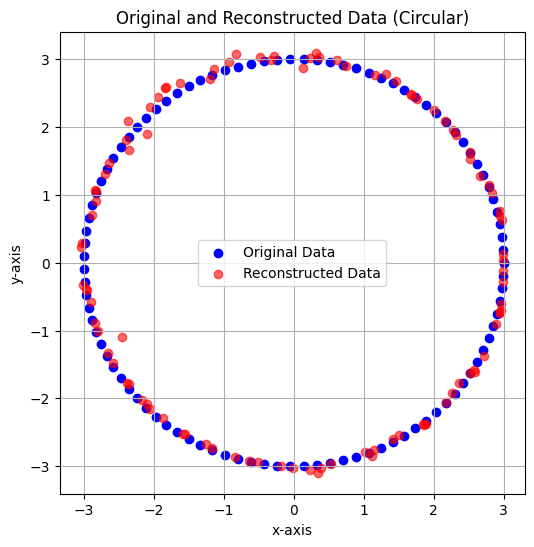

In [12]:
# Plot original data and reconstructed data
plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], color='blue', label='Original Data')  # Original circular data
plt.scatter(reconstructed_data[:, 0], reconstructed_data[:, 1], color='red', alpha=0.6, label='Reconstructed Data')  # Reconstructed data
plt.legend()
plt.title("Original and Reconstructed Data (Circular)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.grid(True)
plt.show()

Based on the training loss values, we can see that the final training loss was approximately 0.6190. Based on our visualization of the reconstructed values vs the original values, we see that the reconstructed values pretty much still form the original circle but include some variations in the points. Overall, this seems like a successful reconstruction that highlights the variability in VAEs. 

# Exploration and Visualization of Latent Space
Visualize the latent space and observe how the circular dataset is represented in 2D.

In [14]:
# Extract averages from reconstructed data
averages = []
with torch.no_grad():
    for batch in dataset_loader:
        batch_data = batch[0]
        _, mu, _ = vae(batch_data)
        averages.append(mu)

# Convert reconstructed data to numpy format for visualization
averages = torch.cat(averages).numpy()

## Visualize the original dataset vs the average vector.

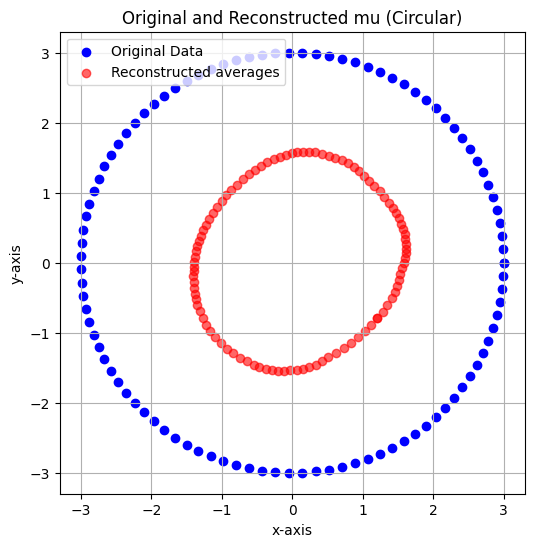

In [16]:
# Plot the latent space in terms of mu
plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], color='blue', label='Original Data')  # Original circular data
plt.scatter(averages[:, 0], averages[:, 1], color='red', alpha=0.6, label='Reconstructed averages')  # Reconstructed mu
plt.legend()
plt.title("Original and Reconstructed mu (Circular)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.grid(True)
plt.show()

## Apply the same principals to a square dataset

In [19]:
# Generate a new synthetic dataset for a square
half_side = 3
pts_per_side = 25

# Bottom edge
x_bottom = np.linspace(-half_side, half_side, pts_per_side, endpoint=False)
y_bottom = np.full(pts_per_side, -half_side)

# Right edge
x_right = np.full(pts_per_side, half_side)
y_right = np.linspace(-half_side, half_side, pts_per_side, endpoint=False)

# Top edge
x_top = np.linspace(half_side, -half_side, pts_per_side, endpoint=False)
y_top = np.full(pts_per_side, half_side)

# Left edge
x_left = np.full(pts_per_side, -half_side)
y_left = np.linspace(half_side, -half_side, pts_per_side, endpoint=False)

# Combine all sides
x_square = np.concatenate([x_bottom, x_right, x_top, x_left])
y_square = np.concatenate([y_bottom, y_right, y_top, y_left])

# Combine x and y into 2D points
square_data = np.stack((x_square, y_square), axis=1)

# Convert data to PyTorch tensors (for use in the model)
square_data = torch.tensor(square_data, dtype=torch.float32)

# Create a DataLoader to iterate over the data in batches
batch_size = 10  # Number of samples per batch
dataset_loader_square = DataLoader(TensorDataset(square_data), batch_size=batch_size, shuffle=True)

In [20]:
# Train the VAE using the new square dataset
num_epochs = 1000  # Number of epochs for training
for epoch in range(num_epochs):
    vae.train()  # Set model to training mode
    total_loss = 0

    for batch in dataset_loader_square:
        batch_data = batch[0]           # Extract batch data
        optimizer.zero_grad()           # Clear gradients from the previous step

        # Forward pass through the VAE
        recon_data, mu, logvar = vae(batch_data)

        # Compute the VAE loss
        loss = vae_loss(recon_data, batch_data, mu, logvar)

        # Backpropagate and update model parameters
        loss.backward()
        optimizer.step()

        total_loss += loss.item()  # Accumulate loss for the epoch

    # Print average loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        avg_loss = total_loss / len(dataset_loader_square)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [100/1000], Loss: 0.7465
Epoch [200/1000], Loss: 0.6941
Epoch [300/1000], Loss: 0.6728
Epoch [400/1000], Loss: 0.6817
Epoch [500/1000], Loss: 0.6590
Epoch [600/1000], Loss: 0.6581
Epoch [700/1000], Loss: 0.6418
Epoch [800/1000], Loss: 0.6257
Epoch [900/1000], Loss: 0.6724
Epoch [1000/1000], Loss: 0.6217


## Examine reconstructed data

In [22]:
# Set the model to evaluation mode
vae.eval()
reconstructed_square_data = []

# Generate reconstructed data from the model
with torch.no_grad():
    for batch in dataset_loader_square:
        batch_data = batch[0]
        recon_batch, _, _ = vae(batch_data)
        reconstructed_square_data.append(recon_batch)

# Convert reconstructed data to numpy format for visualization
reconstructed_square_data = torch.cat(reconstructed_square_data).numpy()
square_data_np = square_data.numpy()

## Visualize comparison of original vs reconstructed data

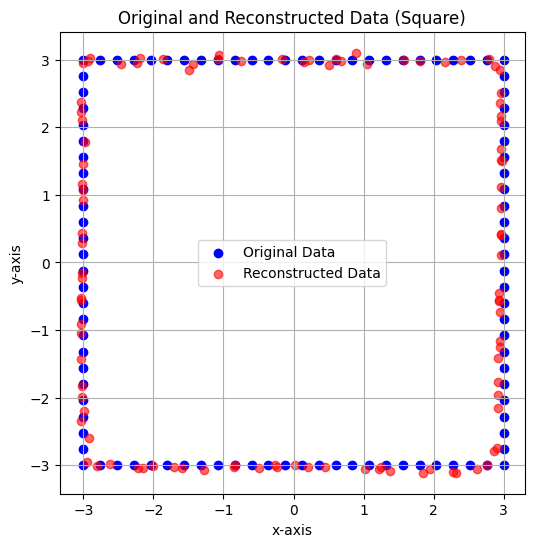

In [24]:
# Plot original data and reconstructed data
plt.figure(figsize=(6, 6))
plt.scatter(square_data_np[:, 0], square_data_np[:, 1], color='blue', label='Original Data')  # Original circular data
plt.scatter(reconstructed_square_data[:, 0], reconstructed_square_data[:, 1], color='red', alpha=0.6, label='Reconstructed Data')  # Reconstructed data
plt.legend()
plt.title("Original and Reconstructed Data (Square)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.grid(True)
plt.show()

# Final Notes
The VAE was also able to reconstruct the square based on the new synthetic data. Similar to the circular dataset, the reconstructed version followed the general shape pretty well while including some variations within each individual dataset, true to the VAE concept.